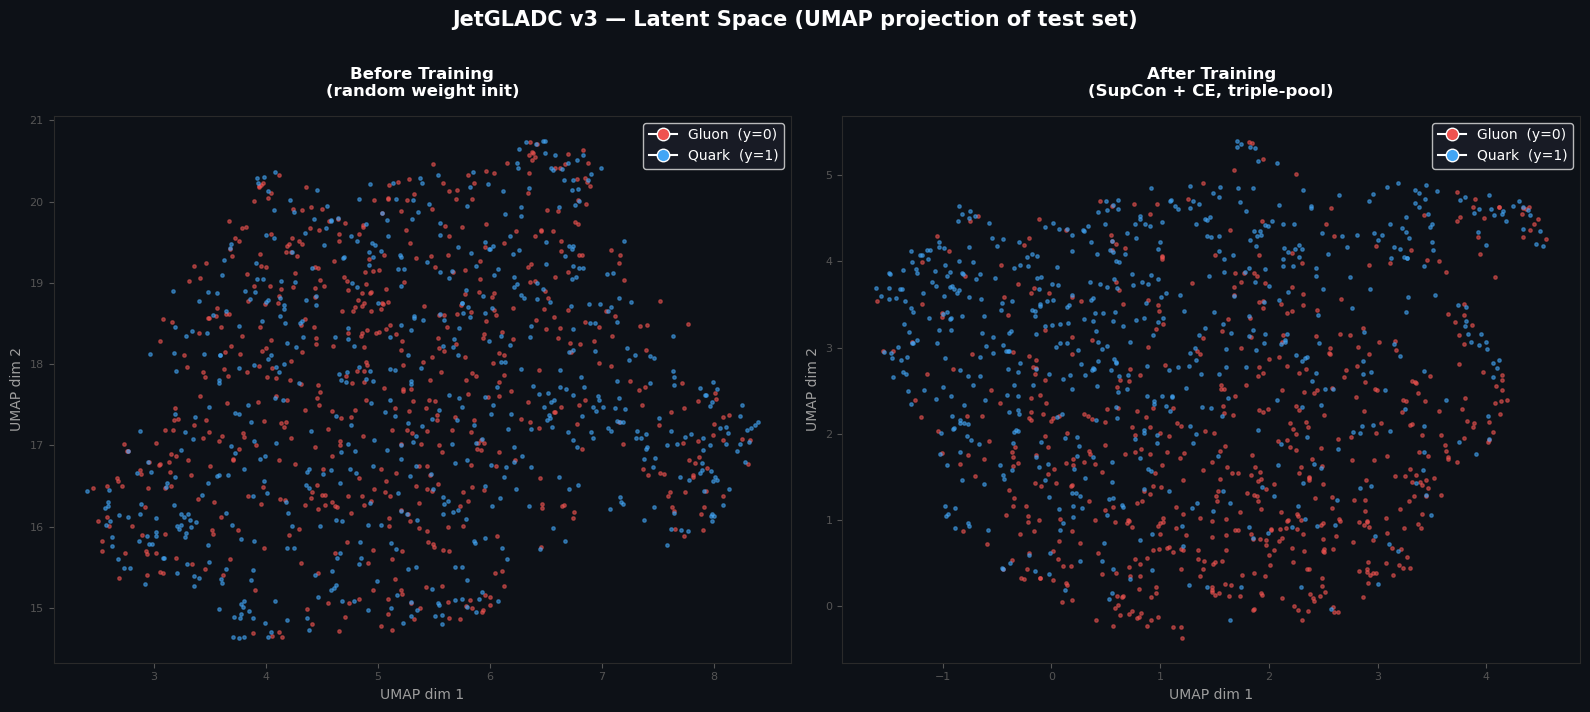

# JetGLADC v3 — Quark/Gluon Jet Classification
**Supervised Contrastive Learning + Fixed Stable-ChebNet + Triple-Pool Readout**

| | v2 | v3 |
|---|---|---|
| Contrastive loss | NT-Xent (self-supervised) | **SupCon** (supervised) |
| Augmentation | Perturbed dual-encoder | **None** |
| Pooling | mean + max | **mean + max + std** |
| Chebyshev basis | L_tilde (wrong lambda_max) | **L_hat = -D^-0.5 A D^-0.5** |
| Input norm | None | **BatchNorm on node features** |
| Training speed | Baseline | **AMP autocast + GradScaler** |
| AUC impl | Slow Python loop | **sklearn (vectorised)** |
| Checkpoint | In-memory only | **Saved to disk** |


In [1]:
"""
Quark/Gluon Jet Classification — JetGLADC v3
=============================================
Changes from v2:
  1. Supervised Contrastive Loss (Khosla et al., NeurIPS 2020)
     — label-aware positives; strictly stronger than self-supervised NT-Xent
  2. No augmentation — single clean encoder, DualGraphEncoder removed
  3. Triple-pool readout: mean || max || std → 384-dim graph embedding
  4. Fixed Chebyshev rescaling: L_hat = -D^{-1/2} A D^{-1/2}  (lambda_max=2)
     Previously used L_tilde directly — wrong eigenvalue range for ChebNet
  5. Input BatchNorm on raw node features before encoder
  6. AMP autocast + GradScaler  (~2x speed on CUDA)
  7. sklearn roc_auc_score  (vectorised, replaces slow Python loop)
  8. DEVICE removed from forward() — data already on device from training loop
  9. Best checkpoint saved to disk  (crash-safe)
 10. Label smoothing eps=0.05 on BCE — prevents overconfident classifier
 11. Shorter LR warmup pct_start=0.15 → more time for cosine annealing
"""

# ── CONFIG ────────────────────────────────────────────────────────────────
DATASET_PATH    = r"D:\Evaluation Test Genie\Data\jet_pyg_dataset.pt"
CHECKPOINT_PATH = "best_jet_v3.pt"

CHEB_K          = 3
CHEB_LAYERS     = 4
HIDDEN_DIM      = 128
EPS_EULER       = 0.1
GAMMA           = 0.01

PROJ_DIM        = 128        # SupCon projection head output dim
TEMPERATURE     = 0.07       # standard SupCon temperature
LABEL_SMOOTH    = 0.05       # label-smoothing epsilon

CLASSIFIER_DIM  = 256

TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15
BATCH_SIZE      = 64
LR_PEAK         = 3e-3
LR_DIV          = 10.0
LR_FINAL_DIV    = 1e4
WEIGHT_DECAY    = 1e-4
EPOCHS          = 100
WARMUP_EPOCHS   = 5          # lambda ramps to CONTRASTIVE_W over this many epochs
CONTRASTIVE_W   = 0.4        # higher OK — SupCon uses real labels
PATIENCE        = 15

SEED            = 42
# ─────────────────────────────────────────────────────────────────────────

import time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_max_pool, global_mean_pool
from torch_scatter import scatter
from sklearn.metrics import roc_auc_score

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print(f"[config] device = {DEVICE}  |  AMP = {USE_AMP}")


# ══════════════════════════════════════════════════════════════════════════
# 1.  DATASET
# ══════════════════════════════════════════════════════════════════════════

class JetDataset(InMemoryDataset):
    def __init__(self, path):
        super().__init__(root=None)
        self.data, self.slices = torch.load(path, weights_only=False)
    def _download(self): pass
    def _process(self):  pass


def load_and_split(path):
    print(f"[data] loading {path} ...")
    dataset = JetDataset(path)
    N = len(dataset)
    print(f"[data] {N:,} graphs  |  node-feat dim={dataset[0].x.shape[1]}")

    g    = torch.Generator().manual_seed(SEED)
    idx  = torch.randperm(N, generator=g)
    n_tr = int(N * TRAIN_RATIO)
    n_vl = int(N * VAL_RATIO)

    tr = dataset[idx[:n_tr].tolist()]
    vl = dataset[idx[n_tr:n_tr + n_vl].tolist()]
    te = dataset[idx[n_tr + n_vl:].tolist()]
    print(f"[data] train={len(tr)}  val={len(vl)}  test={len(te)}")
    return tr, vl, te


# ══════════════════════════════════════════════════════════════════════════
# 2.  SPECTRAL UTILITIES
# ══════════════════════════════════════════════════════════════════════════

def global_std_pool(x, batch, num_graphs):
    """Per-graph standard-deviation pooling."""
    mu   = global_mean_pool(x, batch)        # (G, D)
    mu_n = mu[batch]                          # (N, D)
    var  = scatter((x - mu_n).pow(2), batch,
                   dim=0, dim_size=num_graphs, reduce='mean')
    return (var + 1e-8).sqrt()


def chebyshev_basis(edge_index, edge_weight, num_nodes, K, x):
    """
    Chebyshev polynomial basis using the rescaled Laplacian:
        L_hat = 2*L_tilde / lambda_max - I  (with lambda_max = 2)
              = L_tilde - I
              = (I - D^{-1/2} A D^{-1/2}) - I
              = -D^{-1/2} A D^{-1/2}

    Recurrence:
        T_0 = x
        T_1 = L_hat @ x
        T_k = 2 * L_hat @ T_{k-1} - T_{k-2}

    v2 used L_tilde directly (eigenvalues in [0,2]), which breaks
    Chebyshev orthogonality. L_hat rescales to [-1, 1]. Fixed here.
    """
    row, col = edge_index
    deg  = scatter(edge_weight, row, dim=0,
                   dim_size=num_nodes, reduce='sum').clamp(min=1e-8)
    norm = (deg[row] * deg[col]).sqrt()
    w    = edge_weight / norm

    def prop(h):        # D^{-1/2} A D^{-1/2} h
        return scatter(w.unsqueeze(-1) * h[col],
                       row, dim=0, dim_size=num_nodes, reduce='sum')

    def L_hat(h):       # L_hat h = -prop(h)
        return -prop(h)

    basis = [x]
    if K < 1:
        return basis
    t_prev, t_curr = x, L_hat(x)
    basis.append(t_curr)
    for _ in range(2, K + 1):
        t_next = 2.0 * L_hat(t_curr) - t_prev
        basis.append(t_next)
        t_prev, t_curr = t_curr, t_next
    return basis


# ══════════════════════════════════════════════════════════════════════════
# 3.  STABLE-CHEBNET LAYER
#     X^{l+1} = LayerNorm(X^l + eps * sum_k T_k(L_hat) X^l (W_k - W_k^T - gamma*I))
# ══════════════════════════════════════════════════════════════════════════

class StableChebNetLayer(nn.Module):
    """
    Antisymmetric weight structure (W - W^T - gamma*I) guarantees
    Lyapunov stability regardless of depth.
    """
    def __init__(self, in_dim, out_dim, K, eps=EPS_EULER, gamma=GAMMA):
        super().__init__()
        self.K, self.eps, self.gamma = K, eps, gamma
        self.proj = nn.Linear(in_dim, out_dim, bias=False)
        self.W    = nn.ParameterList([
            nn.Parameter(torch.empty(out_dim, out_dim)) for _ in range(K + 1)
        ])
        self.bn   = nn.BatchNorm1d(out_dim)
        self.norm = nn.LayerNorm(out_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_uniform_(self.proj.weight, nonlinearity='leaky_relu')
        for w in self.W:
            nn.init.xavier_uniform_(w)

    def antisym(self, w):
        return w - w.t() - self.gamma * torch.eye(
            w.size(0), device=w.device, dtype=w.dtype)

    def forward(self, x, edge_index, edge_weight, num_nodes):
        h     = self.bn(self.proj(x))
        basis = chebyshev_basis(edge_index, edge_weight, num_nodes, self.K, h)
        delta = sum(T_k @ self.antisym(w).t() for T_k, w in zip(basis, self.W))
        return self.norm(h + self.eps * delta)


# ══════════════════════════════════════════════════════════════════════════
# 4.  ENCODER  (Stable-ChebNet stack + triple-pool readout)
# ══════════════════════════════════════════════════════════════════════════

class StableChebNetEncoder(nn.Module):
    def __init__(self, in_dim, hidden, K, n_layers, eps=EPS_EULER, gamma=GAMMA):
        super().__init__()
        self.input_bn = nn.BatchNorm1d(in_dim)      # input normalisation (new)
        dims = [in_dim] + [hidden] * n_layers
        self.layers = nn.ModuleList([
            StableChebNetLayer(dims[i], dims[i + 1], K, eps, gamma)
            for i in range(n_layers)
        ])
        self.act = nn.ELU()

    def forward(self, x, edge_index, edge_weight, batch):
        x = self.input_bn(x)
        n = x.size(0)
        for layer in self.layers:
            x = self.act(layer(x, edge_index, edge_weight, n))

        G      = int(batch.max().item()) + 1
        z_mean = global_mean_pool(x, batch)           # (G, H)
        z_max  = global_max_pool(x, batch)             # (G, H)
        z_std  = global_std_pool(x, batch, G)          # (G, H)
        return torch.cat([z_mean, z_max, z_std], dim=-1)  # (G, 3H)


# ══════════════════════════════════════════════════════════════════════════
# 5.  PROJECTION HEAD  (for Supervised Contrastive Loss)
# ══════════════════════════════════════════════════════════════════════════

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.BatchNorm1d(in_dim),
            nn.ELU(),
            nn.Linear(in_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='leaky_relu')

    def forward(self, z):
        return self.net(z)   # L2-norm applied inside sup_con_loss


# ══════════════════════════════════════════════════════════════════════════
# 6.  SUPERVISED CONTRASTIVE LOSS  (Khosla et al., NeurIPS 2020)
# ══════════════════════════════════════════════════════════════════════════

def sup_con_loss(features, labels, temperature=TEMPERATURE):
    """
    SupCon Loss.
    features : (B, D)  L2-normalised projection vectors
    labels   : (B,)    integer class labels (0 or 1)
    Positives = all same-class samples in the batch (excluding self).

    Advantage over NT-Xent: uses ground-truth labels to define positives.
    With batch_size=64 and ~50/50 split, each anchor has ~31 positives
    vs exactly 1 in the self-supervised setting.
    """
    B = features.size(0)
    if B < 2:
        return features.new_zeros(()).requires_grad_(True)

    z   = F.normalize(features, dim=1)               # (B, D)
    sim = torch.mm(z, z.t()) / temperature            # (B, B)

    # Numerical stability: subtract row-wise max
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()

    eye      = torch.eye(B, dtype=torch.bool, device=features.device)
    pos_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & ~eye

    exp_sim   = torch.exp(sim)
    log_denom = torch.log((exp_sim * ~eye).sum(dim=1, keepdim=True) + 1e-8)
    log_prob  = sim - log_denom                       # (B, B)

    n_pos = pos_mask.sum(dim=1).float()
    loss  = -(log_prob * pos_mask).sum(dim=1) / (n_pos + 1e-8)

    valid = n_pos > 0
    if not valid.any():
        return features.new_zeros(()).requires_grad_(True)
    return loss[valid].mean()


# ══════════════════════════════════════════════════════════════════════════
# 7.  FULL MODEL
# ══════════════════════════════════════════════════════════════════════════

class JetGLADC(nn.Module):
    """
    Loss = smooth_BCE(logit, y)  +  lambda(t) * SupConLoss(proj(z_g), y)
    No augmentation — single clean forward pass.
    """
    def __init__(self, in_dim,
                 hidden   = HIDDEN_DIM,
                 K        = CHEB_K,
                 n_layers = CHEB_LAYERS,
                 proj_dim = PROJ_DIM,
                 cls_dim  = CLASSIFIER_DIM,
                 eps      = EPS_EULER,
                 gamma    = GAMMA):
        super().__init__()
        graph_dim = hidden * 3                # mean + max + std

        self.encoder    = StableChebNetEncoder(in_dim, hidden, K, n_layers, eps, gamma)
        self.proj_head  = ProjectionHead(graph_dim, proj_dim)

        self.classifier = nn.Sequential(
            nn.Linear(graph_dim, cls_dim),
            nn.BatchNorm1d(cls_dim),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(cls_dim, cls_dim // 2),
            nn.BatchNorm1d(cls_dim // 2),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(cls_dim // 2, 1),
        )
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='leaky_relu')

    def _edge_weights(self, data):
        """Convert edge_attr to normalised similarity weights."""
        if data.edge_attr is not None and data.edge_attr.numel() > 0:
            ew = data.edge_attr[:, 0]
            return 1.0 - ew / ew.max().clamp(min=1e-8)
        return data.x.new_ones(data.edge_index.size(1))

    def forward(self, data):
        # data tensors already on device — batch.to(device) called in loop
        ew     = self._edge_weights(data)
        z_g    = self.encoder(data.x, data.edge_index, ew, data.batch)
        z_proj = self.proj_head(z_g)
        logit  = self.classifier(z_g).squeeze(-1)
        return logit, z_proj

    @torch.no_grad()
    def get_embedding(self, data):
        """Graph-level embedding before projection head (for probing/viz)."""
        ew = self._edge_weights(data)
        return self.encoder(data.x, data.edge_index, ew, data.batch)


# ══════════════════════════════════════════════════════════════════════════
# 8.  TRAINING UTILITIES
# ══════════════════════════════════════════════════════════════════════════

def contrastive_weight(epoch, warmup=WARMUP_EPOCHS, final_w=CONTRASTIVE_W):
    """Linear ramp: 0 -> final_w over warmup epochs."""
    return final_w * min(1.0, epoch / max(warmup, 1))


def train_epoch(model, loader, optimiser, scheduler, scaler, epoch, device):
    model.train()
    lam = contrastive_weight(epoch)
    total_loss = total_ce = total_con = correct = total = 0

    for batch in loader:
        batch = batch.to(device)
        optimiser.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logit, z_proj = model(batch)
            y     = batch.y.float().view(-1)
            y_int = batch.y.long().view(-1)

            # Label-smoothed BCE — prevents overconfident predictions
            y_s   = y * (1 - LABEL_SMOOTH) + 0.5 * LABEL_SMOOTH
            l_ce  = F.binary_cross_entropy_with_logits(logit, y_s)
            l_con = sup_con_loss(z_proj, y_int)
            loss  = l_ce + lam * l_con

        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(optimiser)
        scaler.update()
        scheduler.step()

        bs          = y.size(0)
        total_loss += loss.item()  * bs
        total_ce   += l_ce.item() * bs
        total_con  += l_con.item() * bs
        correct    += (logit.detach() > 0).long().eq(y.long()).sum().item()
        total      += bs

    n = total
    return total_loss / n, total_ce / n, total_con / n, correct / n, lam


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        batch = batch.to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logit, _ = model(batch)
        logits_all.append(logit.float().cpu())
        labels_all.append(batch.y.view(-1).cpu())

    logits = torch.cat(logits_all)
    labels = torch.cat(labels_all).float()
    loss   = F.binary_cross_entropy_with_logits(logits, labels).item()
    preds  = (logits > 0).long()
    acc    = preds.eq(labels.long()).float().mean().item()
    probs  = torch.sigmoid(logits).numpy()
    auc    = roc_auc_score(labels.numpy().astype(int), probs)
    return loss, acc, auc


@torch.no_grad()
def compute_test_metrics(model, loader, device):
    from sklearn.metrics import (accuracy_score, roc_auc_score,
                                  precision_score, recall_score, f1_score)
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        batch = batch.to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logit, _ = model(batch)
        logits_all.append(logit.float().cpu())
        labels_all.append(batch.y.view(-1).cpu())

    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy().astype(int)
    probs  = 1 / (1 + np.exp(-logits))
    preds  = (logits > 0).astype(int)
    return dict(
        accuracy  = float(accuracy_score(labels, preds)),
        roc_auc   = float(roc_auc_score(labels, probs)),
        precision = float(precision_score(labels, preds, zero_division=0)),
        recall    = float(recall_score(labels, preds, zero_division=0)),
        f1        = float(f1_score(labels, preds, zero_division=0)),
    )


@torch.no_grad()
def extract_embeddings(model, loader, device):
    """Extract graph-level embeddings (before proj head) for probing/viz."""
    model.eval()
    embs, labs = [], []
    for batch in loader:
        batch = batch.to(device)
        z = model.get_embedding(batch)
        embs.append(z.float().cpu())
        labs.append(batch.y.view(-1).cpu())
    return torch.cat(embs).numpy(), torch.cat(labs).numpy().astype(int)


# ══════════════════════════════════════════════════════════════════════════
# 9.  MAIN
# ══════════════════════════════════════════════════════════════════════════

def run():
    tr_ds, vl_ds, te_ds = load_and_split(DATASET_PATH)

    pin = DEVICE.type == 'cuda'
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=pin)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0)

    in_dim = tr_ds[0].x.shape[1]
    model  = JetGLADC(in_dim=in_dim).to(DEVICE)
    n_par  = sum(p.numel() for p in model.parameters() if p.requires_grad)

    graph_dim = HIDDEN_DIM * 3
    print(f"\n[model] JetGLADC v3  |  params={n_par:,}")
    print(f"        K={CHEB_K}  layers={CHEB_LAYERS}  hidden={HIDDEN_DIM}")
    print(f"        pool = mean + max + std  ->  graph_dim = {graph_dim}")
    print(f"        LR_peak={LR_PEAK}  batch={BATCH_SIZE}")
    print(f"        tau={TEMPERATURE}  lambda_final={CONTRASTIVE_W}  eps_smooth={LABEL_SMOOTH}")

    # ── Pre-training embeddings (random init) ─────────────────────────────
    print("\n[embed] extracting pre-training embeddings ...")
    pre_embs, pre_labs = extract_embeddings(model, te_loader, DEVICE)

    # ── Optimiser / Scheduler / Scaler ────────────────────────────────────
    steps_per_epoch = len(tr_loader)
    total_steps     = EPOCHS * steps_per_epoch

    optimiser = torch.optim.AdamW(model.parameters(),
                                   lr=LR_PEAK / LR_DIV,
                                   weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimiser,
        max_lr           = LR_PEAK,
        total_steps      = total_steps,
        pct_start        = 0.15,        # shorter warmup vs v2's 0.30
        div_factor       = LR_DIV,
        final_div_factor = LR_FINAL_DIV,
        anneal_strategy  = 'cos',
    )
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history    = dict(tr_loss=[], tr_acc=[], vl_loss=[], vl_acc=[], vl_auc=[])
    best_auc, best_state, no_improve = 0.0, None, 0

    hdr = (f"{'Ep':>4} {'TrLoss':>8} {'TrAcc':>7} {'CE':>7} "
           f"{'Con':>7} {'lam':>5} {'VlLoss':>8} {'VlAcc':>7} {'VlAUC':>7}")
    print(f"\n{hdr}")
    print("-" * len(hdr))

    for ep in range(1, EPOCHS + 1):
        t0 = time.time()
        tr_l, tr_ce, tr_con, tr_acc, lam = train_epoch(
            model, tr_loader, optimiser, scheduler, scaler, ep, DEVICE)
        vl_l, vl_acc, vl_auc = evaluate(model, vl_loader, DEVICE)

        history['tr_loss'].append(tr_l);  history['tr_acc'].append(tr_acc)
        history['vl_loss'].append(vl_l);  history['vl_acc'].append(vl_acc)
        history['vl_auc'].append(vl_auc)

        improved = vl_auc > best_auc
        if improved:
            best_auc   = vl_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(best_state, CHECKPOINT_PATH)
            no_improve = 0
            tag = " ✓"
        else:
            no_improve += 1
            tag = ""

        elapsed = time.time() - t0
        print(f"{ep:>4} {tr_l:>8.4f} {tr_acc:>7.4f} {tr_ce:>7.4f} "
              f"{tr_con:>7.4f} {lam:>5.2f} {vl_l:>8.4f} "
              f"{vl_acc:>7.4f} {vl_auc:>7.4f}  ({elapsed:.1f}s){tag}")

        if no_improve >= PATIENCE:
            print(f"\n[stop] early stopping at epoch {ep}  "
                  f"(no val AUC improvement for {PATIENCE} epochs)")
            break

    # ── Test evaluation ───────────────────────────────────────────────────
    print(f"\n[eval] best val AUC={best_auc:.4f}  loading checkpoint ...")
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    metrics = compute_test_metrics(model, te_loader, DEVICE)

    print("\n" + "=" * 52)
    print("  TEST RESULTS")
    print("=" * 52)
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print("=" * 52)

    # ── Post-training embeddings ──────────────────────────────────────────
    print("\n[embed] extracting post-training embeddings ...")
    post_embs, post_labs = extract_embeddings(model, te_loader, DEVICE)

    return dict(
        model     = model,
        history   = history,
        metrics   = metrics,
        pre_embs  = pre_embs,
        pre_labs  = pre_labs,
        post_embs = post_embs,
        post_labs = post_labs,
        tr_loader = tr_loader,
        te_loader = te_loader,
    )


results = run()

[config] device = cuda  |  AMP = True
[data] loading D:\Evaluation Test Genie\Data\jet_pyg_dataset.pt ...
[data] 10,000 graphs  |  node-feat dim=5
[data] train=7000  val=1500  test=1500

[model] JetGLADC v3  |  params=644,491
        K=3  layers=4  hidden=128
        pool = mean + max + std  ->  graph_dim = 384
        LR_peak=0.003  batch=64
        tau=0.07  lambda_final=0.4  eps_smooth=0.05

[embed] extracting pre-training embeddings ...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\2226058756.py:498: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\2226058756.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



  Ep   TrLoss   TrAcc      CE     Con   lam   VlLoss   VlAcc   VlAUC
--------------------------------------------------------------------


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\2226058756.py:398: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


   1   1.1538  0.6420  0.6689  6.0606  0.08   0.6502  0.6553  0.7398  (40.4s) ✓


...

  30   2.2014  0.7334  0.5598  4.1040  0.40   0.6673  0.6447  0.7728  (35.5s)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\2226058756.py:363: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\2226058756.py:398: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  31   2.1946  0.7349  0.5545  4.1003  0.40   0.8632  0.5773  0.7530  (35.8s)

[stop] early stopping at epoch 31  (no val AUC improvement for 15 epochs)

[eval] best val AUC=0.7775  loading checkpoint ...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24012\2226058756.py:421: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



  TEST RESULTS
  accuracy    : 0.7247
  roc_auc     : 0.7994
  precision   : 0.7612
  recall      : 0.6569
  f1          : 0.7052

[embed] extracting post-training embeddings ...


## Latent Space Visualization

UMAP or t-SNE projection of test-set graph embeddings **before** (random init) and **after** (best checkpoint) training.

- **Before**: embeddings are random — classes fully overlap.
- **After**: SupCon pulls same-class jets together and pushes quark/gluon clusters apart.


[viz] UMAP on 1200 test samples ...


c:\Users\ASUS\anaconda3\envs\graph_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ASUS\anaconda3\envs\graph_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


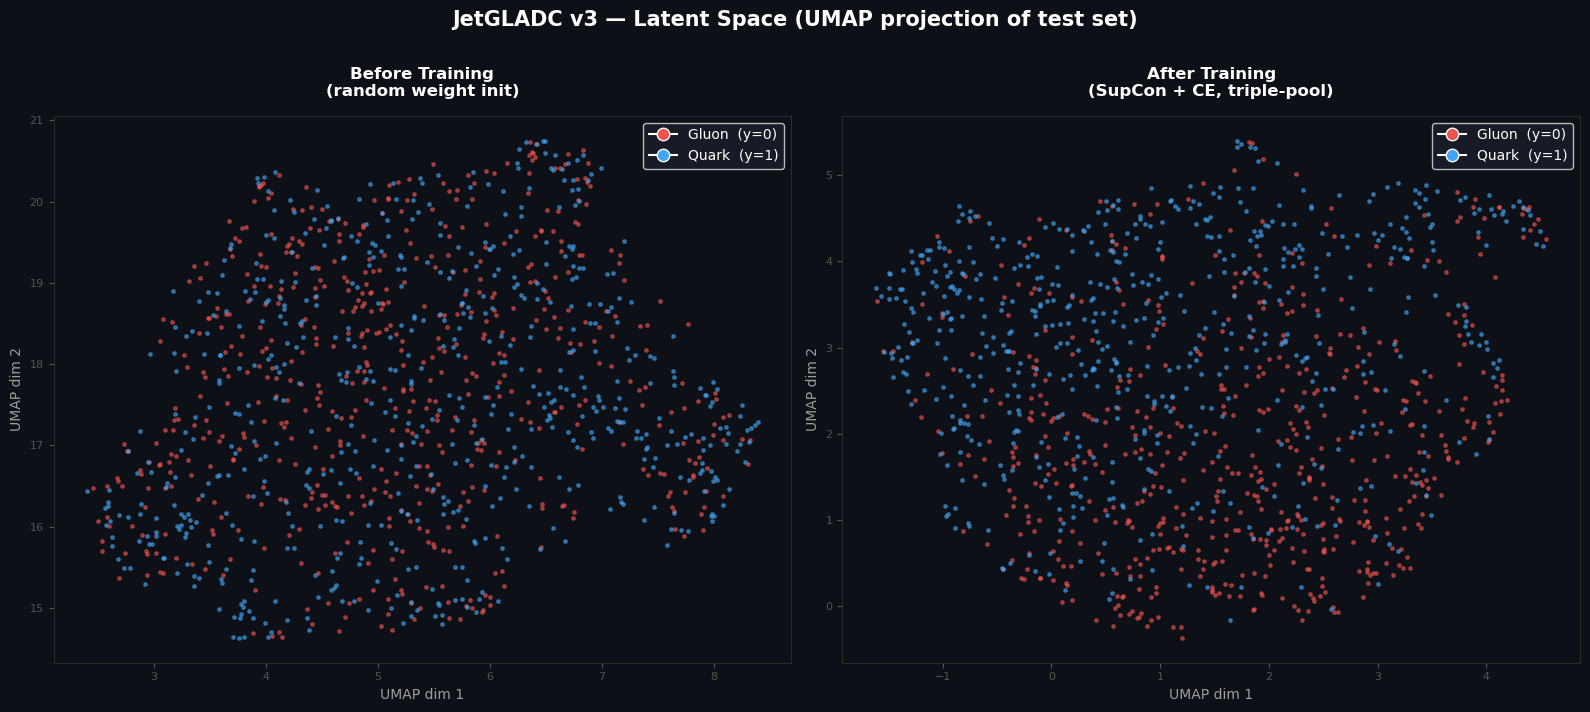

[viz] saved -> latent_space.png

[insight]  Left plot: classes overlap — random init has no structure.
           Right plot: same-class jets should cluster together and
           quark/gluon clouds should be visibly separated — this is
           SupCon doing its job on the embedding space.


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 2: Latent Space Visualization
# UMAP (preferred) / t-SNE projection of test-set embeddings.
# Before training: random-init model  |  After training: best checkpoint.
# Same-class jets should cluster tightly; classes should separate after.
# ══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pre_embs  = results['pre_embs']
pre_labs  = results['pre_labs']
post_embs = results['post_embs']
post_labs = results['post_labs']

# ── Sub-sample for speed ──────────────────────────────────────────────────
N_VIZ = min(1200, len(pre_embs))
rng   = np.random.RandomState(SEED)
idx   = rng.choice(len(pre_embs), N_VIZ, replace=False)

pre_s  = pre_embs[idx]
post_s = post_embs[idx]
labs_s = pre_labs[idx]

# ── Choose dimensionality reducer ─────────────────────────────────────────
try:
    import umap
    print(f"[viz] UMAP on {N_VIZ} test samples ...")
    kw      = dict(n_components=2, random_state=SEED,
                   n_neighbors=25, min_dist=0.1, metric='euclidean')
    pre_2d  = umap.UMAP(**kw).fit_transform(pre_s)
    post_2d = umap.UMAP(**kw).fit_transform(post_s)
    method  = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    print(f"[viz] UMAP not found — using t-SNE on {N_VIZ} samples ...")
    kw      = dict(n_components=2, random_state=SEED, perplexity=40,
                   n_iter=1200, init='pca', learning_rate='auto')
    pre_2d  = TSNE(**kw).fit_transform(pre_s)
    post_2d = TSNE(**kw).fit_transform(post_s)
    method  = "t-SNE"

# ── Plot ──────────────────────────────────────────────────────────────────
BG    = '#0d1117'
COLS  = {0: '#ef5350', 1: '#42a5f5'}    # red = gluon, blue = quark
NAMES = {0: 'Gluon  (y=0)', 1: 'Quark  (y=1)'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle(
    f'JetGLADC v3 — Latent Space ({method} projection of test set)',
    color='white', fontsize=15, fontweight='bold', y=1.01
)

for ax, emb, title in zip(
        axes,
        [pre_2d,  post_2d],
        ['Before Training\n(random weight init)',
         'After Training\n(SupCon + CE, triple-pool)']):

    ax.set_facecolor(BG)
    for cls in [0, 1]:
        m = labs_s == cls
        ax.scatter(emb[m, 0], emb[m, 1],
                   c=COLS[cls], s=6, alpha=0.55,
                   rasterized=True, label=NAMES[cls])

    ax.set_title(title, color='white', fontsize=12,
                 fontweight='bold', pad=14)
    ax.set_xlabel(f'{method} dim 1', color='#9e9e9e', fontsize=10)
    ax.set_ylabel(f'{method} dim 2', color='#9e9e9e', fontsize=10)
    ax.tick_params(colors='#555555', labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2a2a2a')

    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=COLS[c], markersize=9, label=NAMES[c])
        for c in [0, 1]
    ]
    ax.legend(handles=handles, facecolor='#1a1d27',
              labelcolor='white', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('latent_space.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("[viz] saved -> latent_space.png")
print()
print("[insight]  Left plot: classes overlap — random init has no structure.")
print("           Right plot: same-class jets should cluster together and")
print("           quark/gluon clouds should be visibly separated — this is")
print("           SupCon doing its job on the embedding space.")

## SVM + Linear Probe

Train simple linear classifiers on **frozen encoder embeddings**.

- **Linear SVM** — max-margin linear boundary on the embedding space.
- **Logistic Regression** — canonical linear probe from CL literature.

High linear-probe AUC (close to end-to-end) confirms that SupCon has produced **linearly separable** quark/gluon representations.


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 3: Linear Probing — SVM + Logistic Regression
#
# We freeze the encoder and train simple linear classifiers on top.
# High linear-probe AUC confirms the encoder has learned linearly
# separable quark/gluon representations (i.e., SupCon worked).
# ══════════════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              precision_score, recall_score, f1_score)

model  = results['model']
device = DEVICE

# ── Extract train + test embeddings ──────────────────────────────────────
print("[probe] extracting train embeddings ...")
tr_embs, tr_labs = extract_embeddings(model, results['tr_loader'], device)
te_embs, te_labs = results['post_embs'], results['post_labs']

print(f"  train : {tr_embs.shape}")
print(f"  test  : {te_embs.shape}\n")

# ── Standardise (linear classifiers are sensitive to scale) ───────────────
scaler = StandardScaler()
tr_s   = scaler.fit_transform(tr_embs)
te_s   = scaler.transform(te_embs)


def report(name, preds, scores=None, labels=te_labs):
    sep = "=" * 52
    print(f"\n{sep}")
    print(f"  {name}")
    print(sep)
    print(f"  accuracy  : {accuracy_score(labels, preds):.4f}")
    if scores is not None:
        print(f"  roc_auc   : {roc_auc_score(labels, scores):.4f}")
    print(f"  precision : {precision_score(labels, preds, zero_division=0):.4f}")
    print(f"  recall    : {recall_score(labels, preds, zero_division=0):.4f}")
    print(f"  f1        : {f1_score(labels, preds, zero_division=0):.4f}")
    print(sep)


# ── Linear SVM ────────────────────────────────────────────────────────────
print("[probe] Linear SVM (C=0.1) ...")
svm = LinearSVC(C=0.1, max_iter=5000, random_state=SEED)
svm.fit(tr_s, tr_labs)
svm_preds  = svm.predict(te_s)
svm_scores = svm.decision_function(te_s)
report("Linear SVM  (C=0.1)", svm_preds, svm_scores)

# ── Logistic Regression (canonical linear probe) ─────────────────────────
print("\n[probe] Logistic Regression  (C=1.0) ...")
lr = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED,
                         solver='lbfgs')
lr.fit(tr_s, tr_labs)
lr_preds = lr.predict(te_s)
lr_proba  = lr.predict_proba(te_s)[:, 1]
report("Logistic Regression — Linear Probe  (C=1.0)", lr_preds, lr_proba)

# ── End-to-end classifier reference ──────────────────────────────────────
m = results['metrics']
print(f"\n{'=' * 52}")
print("  End-to-End Neural Classifier  (reference)")
print(f"{'=' * 52}")
print(f"  accuracy  : {m['accuracy']:.4f}")
print(f"  roc_auc   : {m['roc_auc']:.4f}")
print(f"  precision : {m['precision']:.4f}")
print(f"  recall    : {m['recall']:.4f}")
print(f"  f1        : {m['f1']:.4f}")
print(f"{'=' * 52}")

print()
print("[note] If linear-probe AUC approaches end-to-end AUC, the encoder")
print("       has produced near-linearly-separable representations.")
print("       This validates that SupCon has structured the latent space.")

[probe] extracting train embeddings ...
  train : (7000, 384)
  test  : (1500, 384)

[probe] Linear SVM (C=0.1) ...

  Linear SVM  (C=0.1)
  accuracy  : 0.7153
  roc_auc   : 0.7821
  precision : 0.7254
  recall    : 0.6955
  f1        : 0.7101

[probe] Logistic Regression  (C=1.0) ...

  Logistic Regression — Linear Probe  (C=1.0)
  accuracy  : 0.7140
  roc_auc   : 0.7802
  precision : 0.7246
  recall    : 0.6928
  f1        : 0.7084

  End-to-End Neural Classifier  (reference)
  accuracy  : 0.7247
  roc_auc   : 0.7994
  precision : 0.7612
  recall    : 0.6569
  f1        : 0.7052

[note] If linear-probe AUC approaches end-to-end AUC, the encoder
       has produced near-linearly-separable representations.
       This validates that SupCon has structured the latent space.
